**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 5: Production Scale — Multi-Chain MCMC & Diagnostics](05_mcmc_production_diagnostics.ipynb) | ⏭️ Next: [Sheet 7: Actionable Systems — Bayesian Decision Theory & Predictive Checks](07_bayesian_decision_theory_and_predictive_checks.ipynb)**

---

# Sheet 6: Dynamic Filtering — Calibrating Memory Decay (γ) for Streaming Systems
### *Solving Asymptotic Blindness and Non-Stationary Drift with Exponential Fading Memory*

In Sheets 1 through 5, we assumed the true parameter $\theta$ is static across all observations. In real-world engineering and production environments, however, systems are **non-stationary**: bug fixes deploy, infrastructure drifts, and failure rates shift overnight.

Under standard Bayes, accumulating thousands of historical runs causes **Asymptotic Blindness (Bayesian Rigidity)**. In this sheet, we derive and calibrate **Dynamic State-Space Filtering with Exponential Memory Decay** (Cauchy functional equation, Poisson hazard rate, West-Harrison filtering), compare it head-to-head against rolling windows, and optimize discount factor $\gamma$ using pre-quential backtesting.

---

### The Non-Stationary Challenge & The Calibration Playbook

In **Sheet 1**, we mastered online conjugate updating for automated tests. But when tests or infrastructure change over time, static Bayesian accumulation causes the posterior to freeze—ignoring fresh incoming failures. We resolve this by introducing **exponential memory decay**:
$$\alpha_t = \gamma \, \alpha_{t-1} + k_t, \qquad \beta_t = \gamma \, \beta_{t-1} + (n_t - k_t)$$

This chapter answers the two deepest engineering and mathematical questions in dynamic Bayesian modeling:
1. **The Mathematical Foundations**: Why is exponential decay the *only* mathematically coherent choice (Cauchy's functional equation, Poisson environmental shocks, West-Harrison state space)? Why do rolling windows and linear decay fail?
2. **The Calibration Playbook**: How do you pick $\gamma$? We explore **four complementary calibration methods** ranging from analytical half-lives to automated pre-quential log-likelihood backtesting.

---

### Table of Contents
1. **Part 1: The Non-Stationary Dilemma & The Rigidity Trap**
2. **Part 2: The Mathematical Justification for Exponential Memory Decay**
3. **Part 3: Head-to-Head Comparison: Exponential vs. Rolling Window vs. Static Bayes**
4. **Part 4: Architectural Matrix (Exponential vs. Rolling vs. Linear vs. Harmonic)**
5. **Part 5: Calibration Method 1 — The Half-Life Rule ($t_{1/2}$)**
6. **Part 6: Calibration Method 2 — Steady-State Effective Sample Size ($N_{\text{eff}}$)**
7. **Part 7: Calibration Method 3 — Responsiveness vs. False Alarm Trade-Off**
8. **Part 8: Calibration Method 4 — Empirical Backtesting & Score Optimization**
9. **Part 9: Advanced Architecture — Event-Triggered & Adaptive Decay**
10. **Part 10: Production Cheat Sheet & Hands-On Challenge Exercises**


## Part 1: The Non-Stationary Dilemma & The Rigidity Trap

Standard Bayesian inference assumes the data-generating process is **stationary** (the true parameter $\theta$ never changes). 

In production software and continuous telemetry, this assumption is false. Code commits break tests, PRs fix regressions, and infrastructure shifts.

### The Asymptotic Blindness Formula
Under static Bayes, cumulative sample size grows as $N_t = N_0 + n \cdot t$. The posterior variance shrinks as $O(1/N_t) \to 0$. 
If a test passes $10,000$ times over 6 months and a commit breaks it today, even after **50 consecutive failures**, the static Bayesian posterior is:
$$\mathbb{E}[\theta] = \frac{1 + 50}{10,000 + 50} \approx 0.5\%$$
The model is **completely paralyzed by ancient history**. We must decay the past.

---

### The Sclerotic Bureaucrat vs. The Goldfish: The Memory Dilemma

To understand why stationary Bayesian updating fails on live systems, consider three archetypes of memory:

| Memory Archetype | Historical Weighting Profile | Operational Failure Mode / Trade-off |
| :--- | :--- | :--- |
| **1. Static Bayes**<br>*(The Sclerotic Bureaucrat)* | **Flat Uniform Weight ($w_t = 1.0$) across all time**: Every observation from years ago retains identical voting power to data collected five minutes ago. | **Paralyzing Inertia**: As $N \to 10,000+$, prior pseudo-counts overwhelm new data. When a critical bug is deployed or fixed, the model takes months to reflect reality. |
| **2. Rolling Window**<br>*(The Goldfish)* | **Step-Function Cutoff ($w_t = 1.0$ for $t \le W$, $w_t = 0.0$ for $t > W$)**: Full memory inside the window, total amnesia beyond it. | **The Cliff-Edge Shock**: Observations abruptly drop off the edge. Error estimates suddenly plummet not because the system improved, but because an old event crossed the arbitrary boundary. |
| **3. Exponential Decay**<br>*(The Adaptive Engineer)* | **Smooth Geometric Discounting ($w_t = \gamma^t$, $\gamma \in (0, 1)$)**: Today receives weight $1.0$, yesterday $\gamma$, last week $\gamma^7$. | **Optimal Balance**: Continuous, monotonic decay with no cliff edges. Allows analytic conjugate updating while maintaining a finite effective sample size $N_{\text{eff}} = \frac{1}{1 - \gamma}$. |

1. **The Sclerotic Bureaucrat (Static Bayes, $\gamma = 1.0$)**:
   - Accumulates evidence indefinitely without discounting ($\alpha_n = \alpha_0 + \sum k_i$).
   - After $10,000$ runs, its prior weight $\alpha + \beta = 10,000$ is so colossal that incoming fresh data has almost zero voting power ($1 / 10,001$). When an engineer merges a fix, the bureaucrat refuses to update its opinion for months!
2. **The Goldfish (Rolling 10-Day Window)**:
   - Treats any observation from Day 1 to Day 9 with $100\%$ weight, but on Day 10, that observation **abruptly falls off the cliff** to $0\%$ weight.
   - **The Cliff-Edge Shock**: If a catastrophic bug occurred 10 days ago, tomorrow your error rate will suddenly plunge—not because the system improved today, but because an old event fell off the arbitrary window edge!
3. **The Adaptive Engineer (Exponential Memory Decay, $\gamma \in (0, 1)$)**:
   - Applies a smooth geometric decay factor $\gamma^t$. Today's data gets full weight $1.0$; yesterday's gets $\gamma$; last week's gets $\gamma^7$.
   - **The Golden Property**: No cliff edges, no arbitrary cutoffs, and mathematically bounded memory that never freezes ($N_{\text{eff}} = \frac{1}{1 - \gamma}$).


## Part 2: The Mathematical Justification for Exponential Memory Decay

Why must memory decay be **exponential** rather than linear or a rolling 14-day window? There are **four converging mathematical reasons**:

### 1. Cauchy's Functional Equation & $O(1)$ Streaming
In streaming microservices, we cannot store the entire history of millions of individual runs. To update today's state from yesterday's summary state in **$O(1)$ constant time and $O(1)$ space**, the memory weighting function $w(t)$ must satisfy the **homomorphism property**:
$$w(t_1 + t_2) = w(t_1) \cdot w(t_2)$$
Cauchy (1821) proved that the **only** continuous, non-zero functions satisfying this are exponentials:
$$w(t) = e^{-\lambda t} = \gamma^t$$
Any other decay function (e.g. rolling window, linear) mathematically requires storing the entire raw event log in memory.

### 2. Constant Hazard Rate of Environmental Shocks (Poisson Process)
Code commits, dependency bumps, and environment disruptions arrive according to a Poisson process with constant hazard rate $\lambda$. The survival probability of zero disruptions over interval $\Delta t$ is strictly exponential:
$$P(\text{system unchanged over } \Delta t) = e^{-\lambda \Delta t} = \gamma^{\Delta t}$$
By the Law of Total Probability, older evidence must be discounted by the probability that the underlying process has remained unchanged.

### 3. West & Harrison Dynamic Conjugate Filtering (Kalman Equivalence)
West & Harrison (1997) proved that discounting Fisher information by $\gamma \in (0, 1)$ injects stochastic variance into the state while **keeping the posterior in exact closed-form Beta distributions**, avoiding the computational cost of particle filters.

### 4. Bounded Information Horizon (Geometric Series)
Because $\sum_{j=0}^\infty \gamma^j = \frac{1}{1 - \gamma}$, effective sample size converges to a stable stationary ceiling: $N_{\text{eff}} = \frac{N}{1 - \gamma}$.

---

## Part 3: Head-to-Head Comparison: Exponential vs. Rolling Window vs. Static Bayes

To witness the memory dilemma in action, we simulate a realistic 40-day software lifecycle:
- **Days 1–10 (Healthy Baseline)**: Test runs pass cleanly ($0\%$ failure rate).
- **Days 11–25 (Critical Regression)**: A broken database migration causes a surge of $40\%$ failures.
- **Days 26–40 (Post-Fix Recovery)**: The developer deploys a fix, and all runs return to $100\%$ pass rate.

Watch how the three paradigms respond:
1. **Static Bayes ($\gamma = 1.0$)**: Slow to detect the regression, and **completely paralyzed** after the fix—refusing to clear the test!
2. **Rolling 10-Day Window**: Detects the regression, but exhibits jagged, step-like cliff-edge drops when past days expire.
3. **Exponential Decay ($\gamma = 0.90$, half-life $\approx 6.6$ days)**: Rapidly detects the spike and smoothly, monotonically recovers to zero.

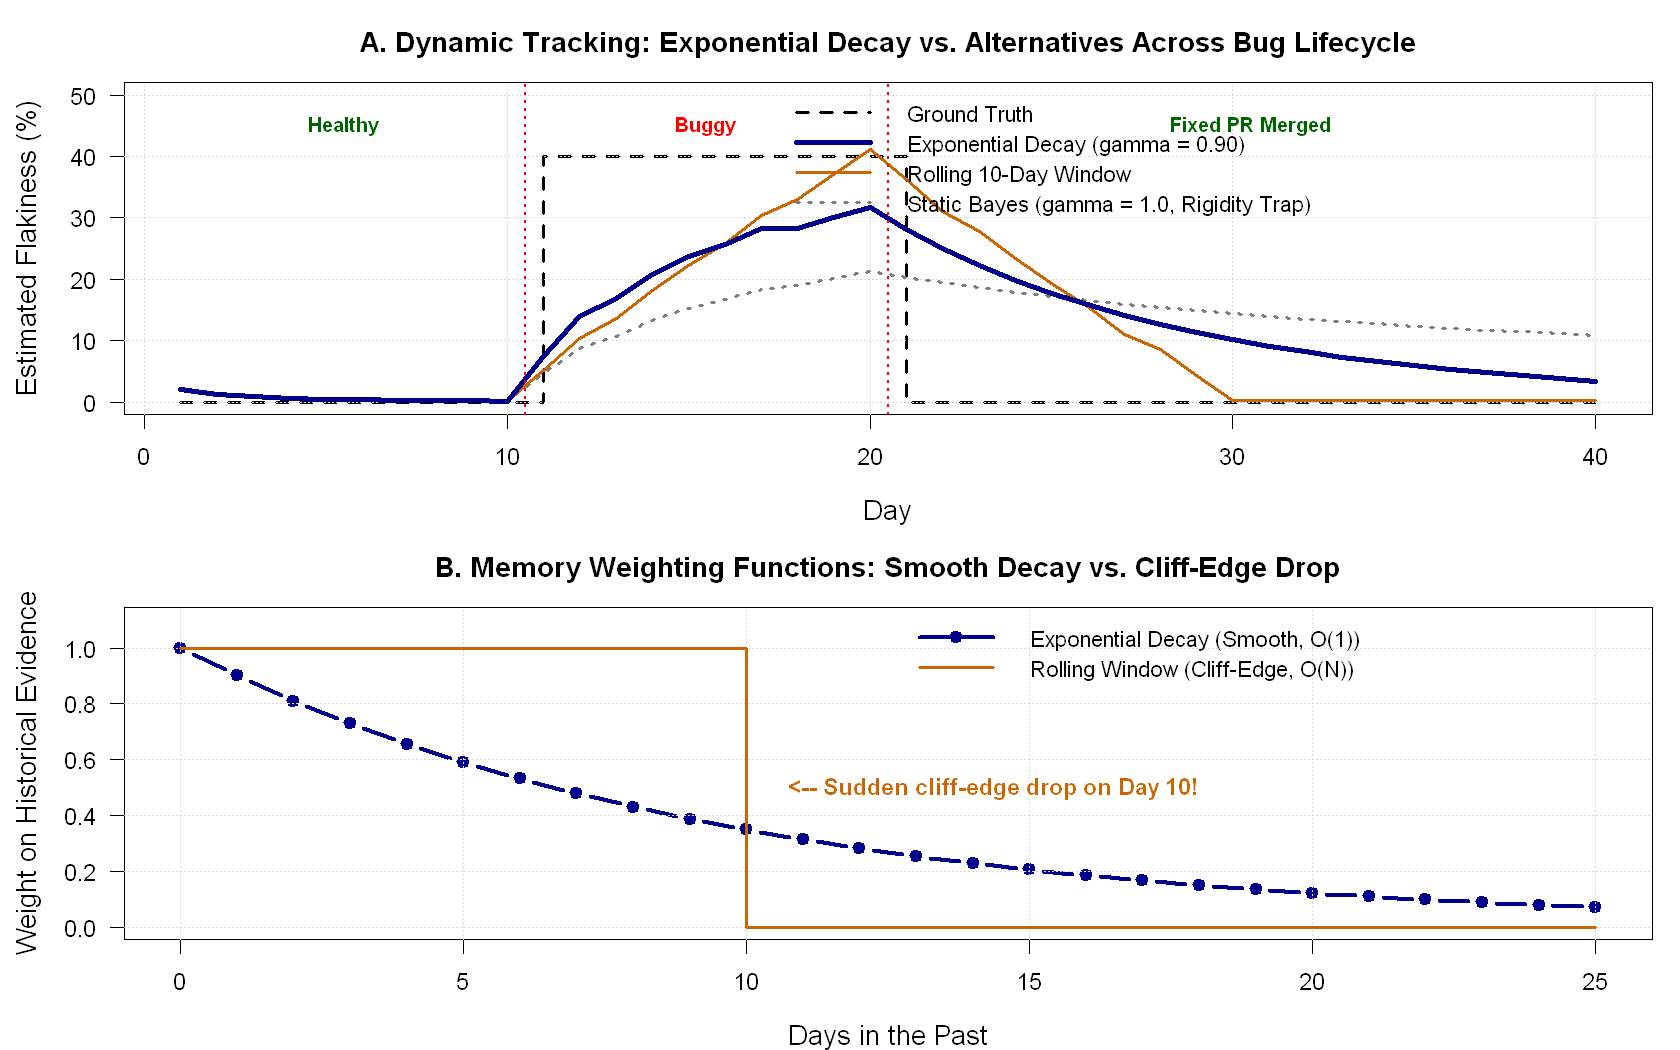

In [1]:
# Simulation: Exponential Decay vs. Rolling Window vs. Static Bayes
options(repr.plot.width = 12, repr.plot.height = 7.5, repr.plot.res = 140)
set.seed(42)
days <- 40
runs_per_day <- 25

# 40-Day Lifecycle: Healthy (0%) -> Buggy (40%) -> Fixed (0%)
true_theta <- c(rep(0.00, 10), rep(0.40, 10), rep(0.00, 20))
daily_fails <- rbinom(days, size = runs_per_day, prob = true_theta)

# 1. Static Bayes (No Decay, gamma = 1.0)
static_mean <- numeric(days)
a_s <- 1; b_s <- 19
for (d in 1:days) {
  a_s <- a_s + daily_fails[d]; b_s <- b_s + (runs_per_day - daily_fails[d])
  static_mean[d] <- a_s / (a_s + b_s)
}

# 2. Exponential Decay (gamma = 0.90, half-life ~ 6.6 days)
gamma <- 0.90
exp_mean <- numeric(days)
a_e <- 1; b_e <- 19
for (d in 1:days) {
  a_e <- gamma * a_e + daily_fails[d]; b_e <- gamma * b_e + (runs_per_day - daily_fails[d])
  exp_mean[d] <- a_e / (a_e + b_e)
}

# 3. Rolling 10-Day Window (Unweighted memory)
roll_mean <- numeric(days)
for (d in 1:days) {
  start_d <- max(1, d - 9)
  roll_mean[d] <- (1 + sum(daily_fails[start_d:d])) / (20 + sum(rep(runs_per_day, d - start_d + 1)))
}

# 2-Panel Plot
par(mfrow = c(2, 1), mar = c(4, 4.5, 3, 1))

# Panel 1: Response across Lifecycle
plot(1:days, true_theta * 100, type = "s", col = "black", lty = 2, lwd = 2.5, las = 1,
     ylim = c(0, 50), xlab = "Day", ylab = "Estimated Flakiness (%)",
     main = "A. Dynamic Tracking: Exponential Decay vs. Alternatives Across Bug Lifecycle",
     cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")
lines(1:days, static_mean * 100, col = "gray50", lwd = 2.5, lty = 3)
lines(1:days, roll_mean * 100, col = "darkorange3", lwd = 2.5)
lines(1:days, exp_mean * 100, col = "darkblue", lwd = 3.5)
abline(v = c(10.5, 20.5), col = "red", lty = 3, lwd = 1.5)
text(5.5, 45, "Healthy", cex = 0.85, col = "darkgreen", font = 2)
text(15.5, 45, "Buggy", cex = 0.85, col = "red", font = 2)
text(30.5, 45, "Fixed PR Merged", cex = 0.85, col = "darkgreen", font = 2)

legend("topright", legend = c("Ground Truth", "Exponential Decay (gamma = 0.90)", 
                              "Rolling 10-Day Window", "Static Bayes (gamma = 1.0, Rigidity Trap)"),
       col = c("black", "darkblue", "darkorange3", "gray50"),
       lty = c(2, 1, 1, 3), lwd = c(2.5, 3.5, 2.5, 2.5), bty = "n", cex = 0.95)

# Panel 2: Memory Weight Functions (Cliff-Edge Drop)
t_lags <- 0:25
w_exp <- gamma^t_lags
w_roll <- ifelse(t_lags < 10, 1.0, 0.0)

plot(t_lags, w_exp, type = "b", pch = 19, col = "darkblue", lwd = 3, las = 1,
     ylim = c(0, 1.1), xlab = "Days in the Past", ylab = "Weight on Historical Evidence",
     main = "B. Memory Weighting Functions: Smooth Decay vs. Cliff-Edge Drop",
     cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")
lines(t_lags, w_roll, type = "s", col = "darkorange3", lwd = 2.5)
text(10.5, 0.5, "<-- Sudden cliff-edge drop on Day 10!", col = "darkorange3", pos = 4, font = 2)

legend("topright", legend = c("Exponential Decay (Smooth, O(1))", "Rolling Window (Cliff-Edge, O(N))"),
       col = c("darkblue", "darkorange3"), lty = 1, pch = c(19, NA), lwd = c(3, 2.5), bty = "n", cex = 0.95)

par(mfrow = c(1, 1))


## Part 4: Architectural Matrix of Memory Models

| Fading Memory Model | Formula $w(t)$ | Complexity | Memory Required | Mathematical Flaws & Failure Modes |
| :--- | :--- | :---: | :---: | :--- |
| **Exponential Decay** | **$\gamma^t = e^{-\lambda t}$** | **$O(1)$** | **2 floats ($\alpha, \beta$)** | **None.** Smooth, memoryless, matches Poisson shocks, strictly conjugate. |
| **Static Bayes (No Decay)** | $w(t) = 1$ | $O(1)$ | 2 floats | **Bayesian Rigidity Trap**: Paralyzed by ancient history as $N \to \infty$. |
| **Rolling Rectangular Window** | $\mathbf{1}_{\{t \le W\}}$ | $O(N)$ | Full event array | **Cliff-Edge Artifacts**: Test score jumps abruptly when old runs drop off. |
| **Linear Decay** | $\max(0, 1 - c \cdot t)$ | $O(N)$ | Full event array | Reaches zero/negative weights, violating probability axioms. |
| **Harmonic Decay** | $1 / t$ | $O(N)$ | Full event array | Harmonic series diverges ($\sum 1/t = \infty$), failing to prevent rigidity. |

## Part 5: Calibration Method 1 — The Half-Life Rule ($t_{1/2}$)

The **memory half-life** $t_{1/2}$ is the elapsed time until an observation retains exactly $50\%$ of its initial weight:
$$\gamma^{t_{1/2}} = 0.5 \implies t_{1/2} = \frac{\ln(0.5)}{\ln(\gamma)}$$

Conversely, if your team works in 2-week sprints (14 days) and wants evidence from the previous sprint to retain $25\%$ weight, set $\gamma = 0.25^{1/14} \approx 0.906$.

=== Memory Half-Life for Different Gamma Values ===


Gamma = 0.80  -->  Daily Decay: 20.0%  -->  Half-Life:   3.1 days
Gamma = 0.88  -->  Daily Decay: 12.0%  -->  Half-Life:   5.4 days
Gamma = 0.92  -->  Daily Decay:  8.0%  -->  Half-Life:   8.3 days
Gamma = 0.95  -->  Daily Decay:  5.0%  -->  Half-Life:  13.5 days
Gamma = 0.98  -->  Daily Decay:  2.0%  -->  Half-Life:  34.3 days


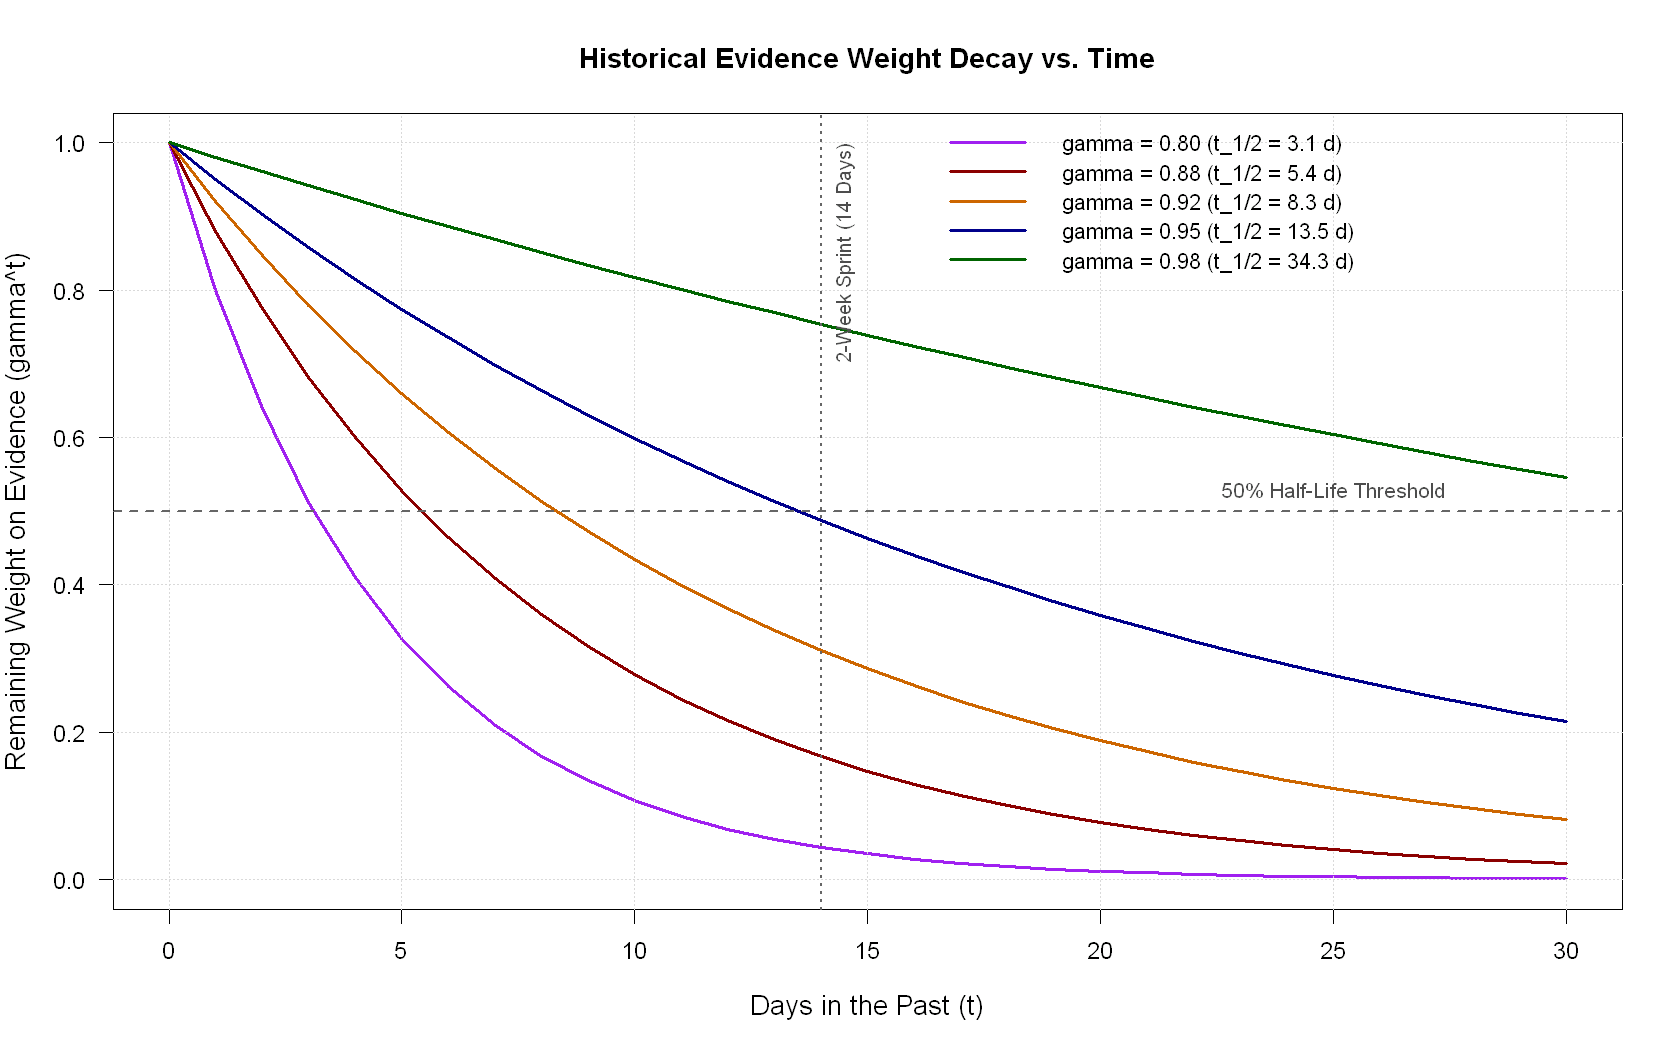

In [2]:
# Calibration Method 1: Half-Life Analysis
gammas <- c(0.80, 0.88, 0.92, 0.95, 0.98)
half_lives <- log(0.5) / log(gammas)

cat("=== Memory Half-Life for Different Gamma Values ===\n")
for (i in seq_along(gammas)) {
  cat(sprintf("Gamma = %.2f  -->  Daily Decay: %4.1f%%  -->  Half-Life: %5.1f days\n",
              gammas[i], 100 * (1 - gammas[i]), half_lives[i]))
}

# Plot Exponential Weight Decay Curves Over 30 Days
days_vec <- 0:30
colors <- c("purple", "darkred", "darkorange3", "darkblue", "darkgreen")

plot(days_vec, gammas[1]^days_vec, type = "l", lwd = 2.5, col = colors[1], las = 1,
     ylim = c(0, 1), xlab = "Days in the Past (t)", ylab = "Remaining Weight on Evidence (gamma^t)",
     main = "Historical Evidence Weight Decay vs. Time", cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")

for (i in 2:length(gammas)) {
  lines(days_vec, gammas[i]^days_vec, lwd = 2.5, col = colors[i])
}
abline(h = 0.5, lty = 2, col = "gray40", lwd = 1.5)
text(25, 0.53, "50% Half-Life Threshold", col = "gray30", cex = 0.9)
abline(v = 14, lty = 3, col = "gray40", lwd = 1.5)
text(14.5, 0.85, "2-Week Sprint (14 Days)", srt = 90, col = "gray30", cex = 0.85)

legend("topright", legend = sprintf("gamma = %.2f (t_1/2 = %.1f d)", gammas, half_lives),
       col = colors, lwd = 2.5, bty = "n", cex = 0.95)


## Part 6: Calibration Method 2 — Steady-State Effective Sample Size ($N_{\text{eff}}$)

Under continuous operation with $N$ runs per day, the total accumulated pseudo-counts form a geometric progression converging to:
$$N_{\text{eff}} = \lim_{T \to \infty} \sum_{t=0}^{T-1} N \, \gamma^t = \frac{N}{1 - \gamma}$$

This gives the **information horizon** of the filter: $\gamma = 0.92$ at 20 runs/day equals having a permanent memory of exactly 250 test runs.

=== Asymptotic Effective Sample Size Ceiling (N = 20 runs/day) ===


Gamma = 0.80  -->  Max Information Horizon:  100 equivalent test runs
Gamma = 0.88  -->  Max Information Horizon:  167 equivalent test runs
Gamma = 0.92  -->  Max Information Horizon:  250 equivalent test runs
Gamma = 0.95  -->  Max Information Horizon:  400 equivalent test runs
Gamma = 0.98  -->  Max Information Horizon: 1000 equivalent test runs


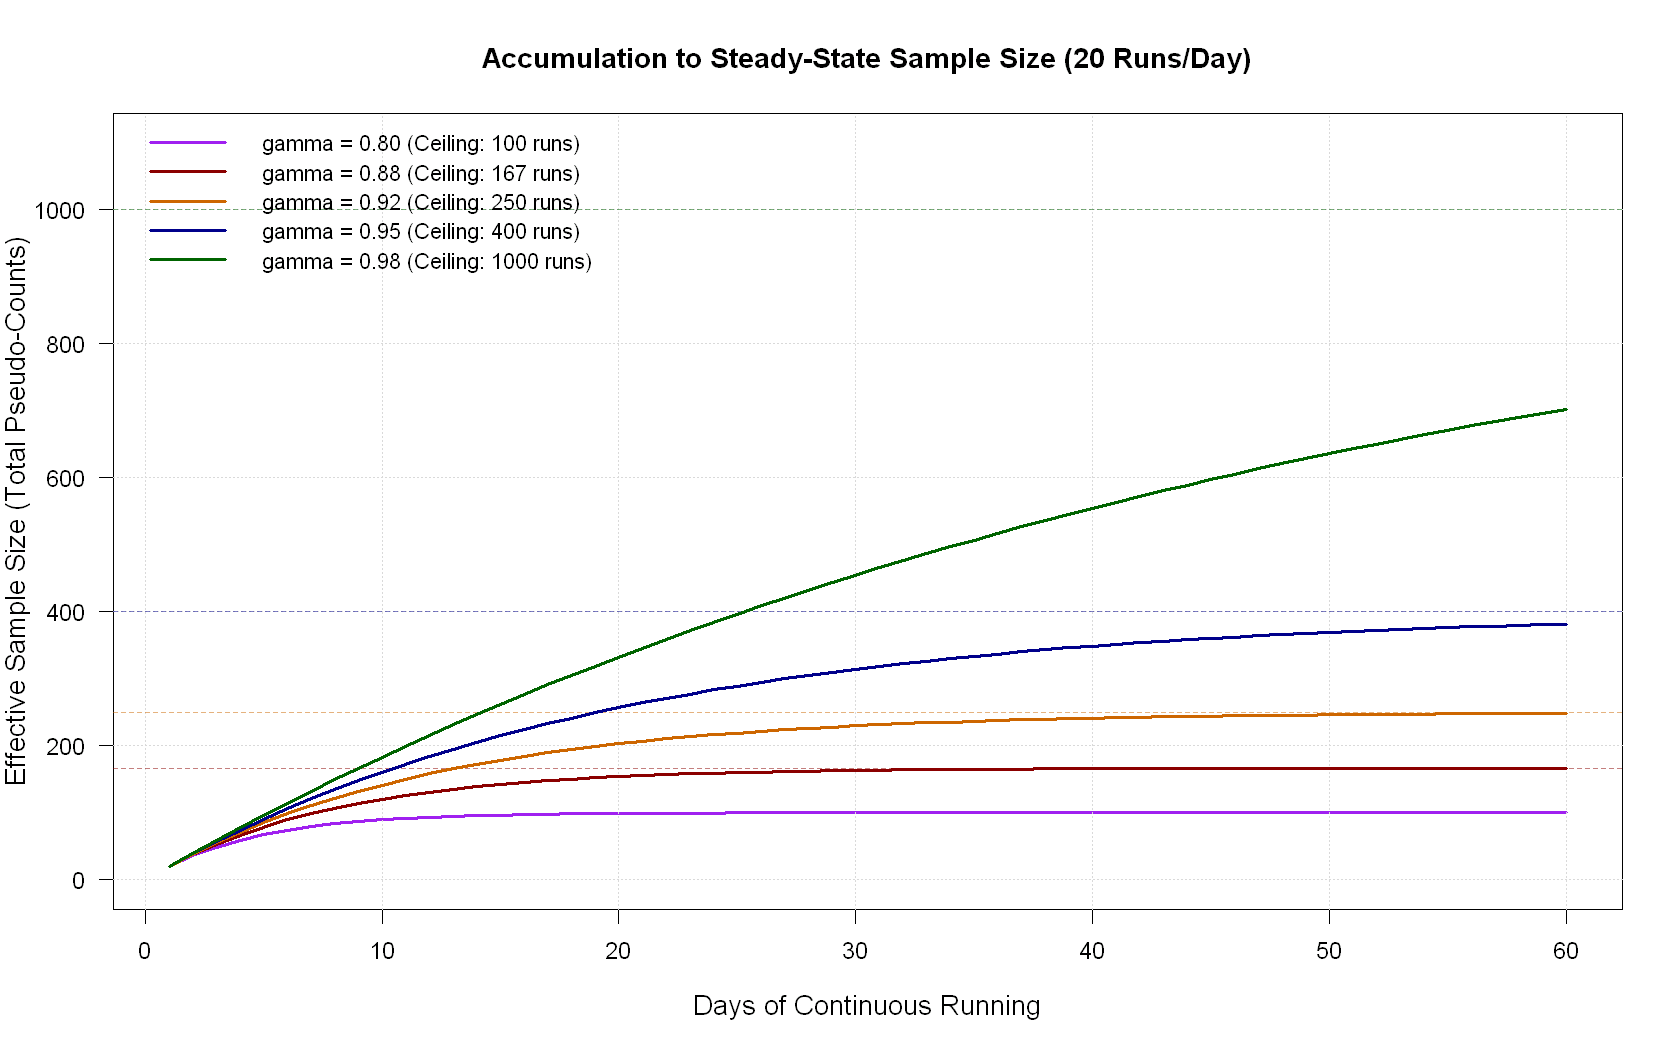

In [3]:
# Calibration Method 2: Effective Sample Size Accumulation
N_daily <- 20
days_vec <- 1:60
N_eff_ceilings <- N_daily / (1 - gammas)

cat("=== Asymptotic Effective Sample Size Ceiling (N = 20 runs/day) ===\n")
for (i in seq_along(gammas)) {
  cat(sprintf("Gamma = %.2f  -->  Max Information Horizon: %4.0f equivalent test runs\n",
              gammas[i], N_eff_ceilings[i]))
}

plot(days_vec, N_daily * (1 - gammas[1]^days_vec) / (1 - gammas[1]), type = "l", lwd = 2.5,
     col = colors[1], las = 1, ylim = c(0, 1100),
     xlab = "Days of Continuous Running", ylab = "Effective Sample Size (Total Pseudo-Counts)",
     main = "Accumulation to Steady-State Sample Size (20 Runs/Day)",
     cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")

for (i in 2:length(gammas)) {
  lines(days_vec, N_daily * (1 - gammas[i]^days_vec) / (1 - gammas[i]), lwd = 2.5, col = colors[i])
  abline(h = N_eff_ceilings[i], lty = 2, col = adjustcolor(colors[i], alpha.f = 0.5))
}

legend("topleft", legend = sprintf("gamma = %.2f (Ceiling: %d runs)", gammas, round(N_eff_ceilings)),
       col = colors, lwd = 2.5, bty = "n", cex = 0.95)


## Part 7: Calibration Method 3 — Responsiveness vs. False Alarm Trade-Off

Lower $\gamma$ reacts faster to newly introduced bugs, but increases false alarm rates during healthy periods.
We simulate a 30-day lifecycle:
- **Days 1-10**: 1% healthy
- **Days 11-14**: 25% flaky bug
- **Days 15-30**: Bug fixed (0%)

We measure the **Quarantine Recovery Time**: how many days after the fix does the $95\%$ upper bound drop back below $5\%$?

=== Quarantine Recovery Days (Post-Fix on Day 14) ===


Gamma = 0.80  -->  De-quarantined on Day 24 (10 days after bug fix)
Gamma = 0.92  -->  De-quarantined on Day 29 (15 days after bug fix)
Gamma = 0.98  -->  STILL QUARANTINED after 16 days!


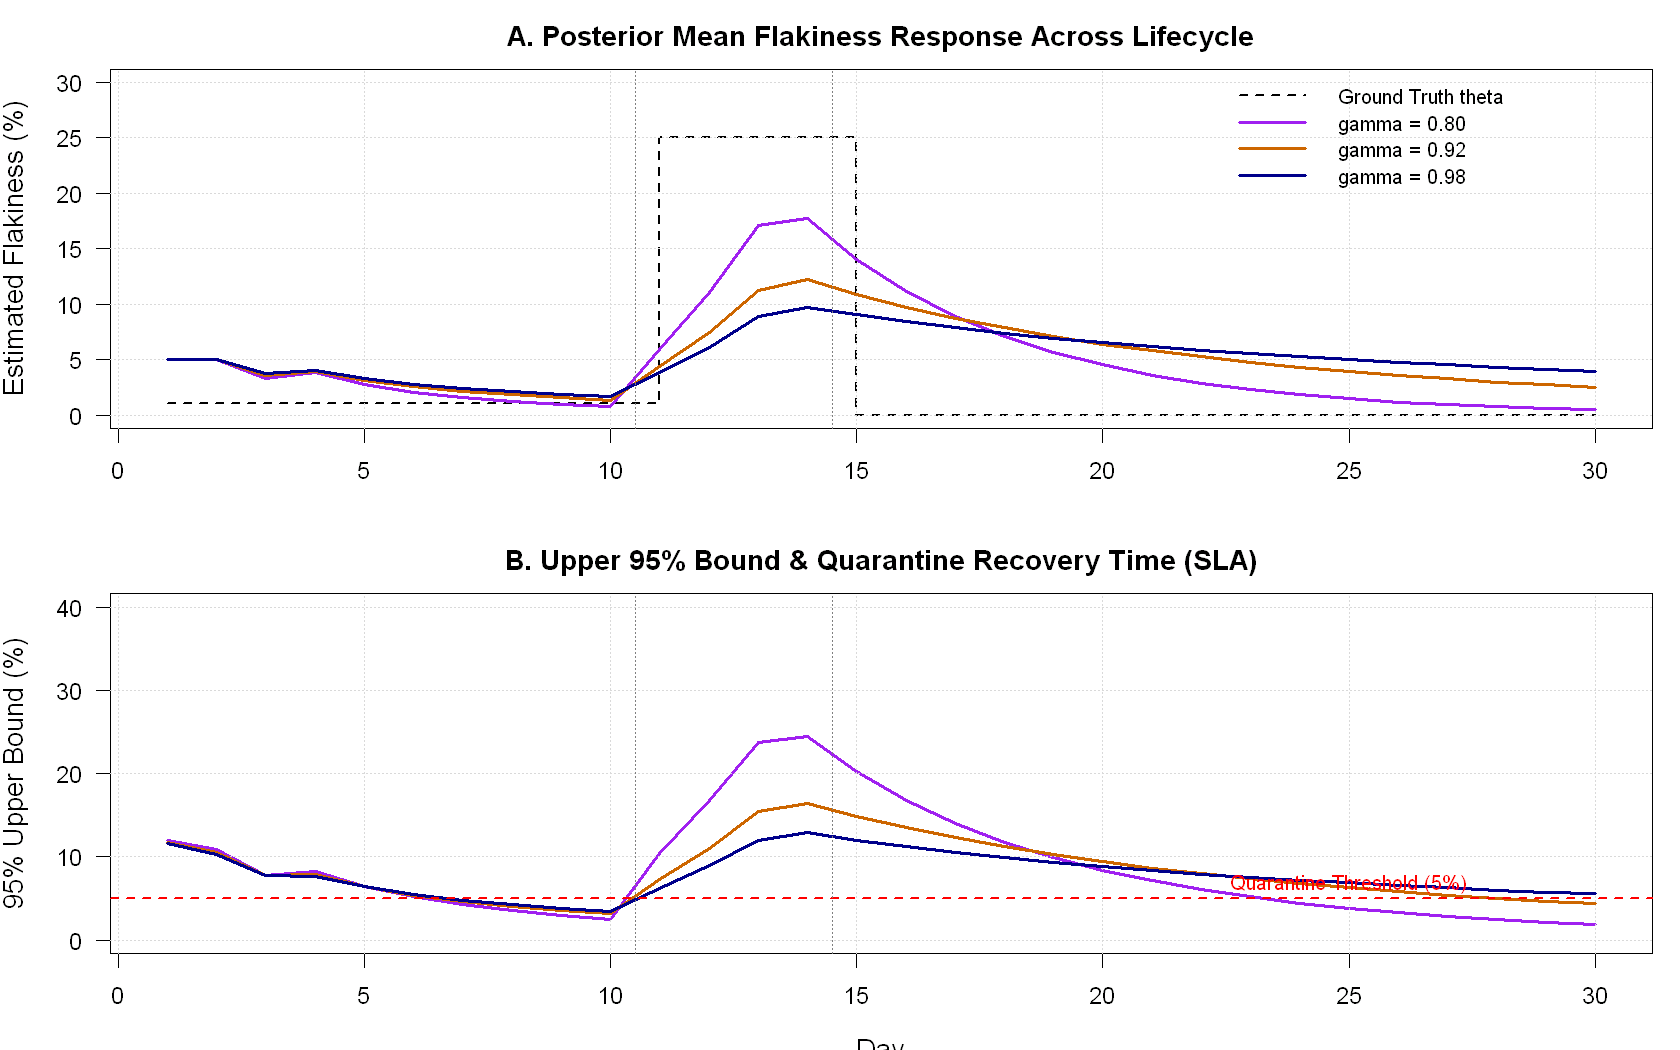

In [4]:
# Calibration Method 3: Lifecycle Simulation
set.seed(42)
days_total <- 30
runs_per_day <- 20
true_theta_sim <- c(rep(0.01, 10), rep(0.25, 4), rep(0.00, 16))
daily_failures <- rbinom(days_total, size = runs_per_day, prob = true_theta_sim)

test_gammas <- c(0.80, 0.92, 0.98)
sim_colors  <- c("purple", "darkorange3", "darkblue")

results_mean <- matrix(0, nrow = days_total, ncol = length(test_gammas))
results_q95  <- matrix(0, nrow = days_total, ncol = length(test_gammas))

for (g_idx in seq_along(test_gammas)) {
  g <- test_gammas[g_idx]
  a <- 1; b <- 19
  for (d in 1:days_total) {
    a <- g * a + daily_failures[d]
    b <- g * b + (runs_per_day - daily_failures[d])
    results_mean[d, g_idx] <- 100 * (a / (a + b))
    results_q95[d, g_idx]  <- 100 * qbeta(0.95, a, b)
  }
}

par(mfrow = c(2, 1), mar = c(3.5, 4, 2.5, 1))

# Panel A: Posterior Mean
plot(1:days_total, 100 * true_theta_sim, type = "s", lwd = 2, col = "black", lty = 2, las = 1,
     ylim = c(0, 30), xlab = "", ylab = "Estimated Flakiness (%)",
     main = "A. Posterior Mean Flakiness Response Across Lifecycle", cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")
for (g_idx in seq_along(test_gammas)) {
  lines(1:days_total, results_mean[, g_idx], lwd = 2.5, col = sim_colors[g_idx])
}
abline(v = c(10.5, 14.5), col = "gray50", lty = 3)
legend("topright", legend = c("Ground Truth theta", sprintf("gamma = %.2f", test_gammas)),
       col = c("black", sim_colors), lty = c(2, 1, 1, 1), lwd = c(2, 2.5, 2.5, 2.5), bty = "n", cex = 0.85)

# Panel B: Upper 95% Bound
plot(1:days_total, results_q95[, 1], type = "l", lwd = 2.5, col = sim_colors[1], las = 1,
     ylim = c(0, 40), xlab = "Day", ylab = "95% Upper Bound (%)",
     main = "B. Upper 95% Bound & Quarantine Recovery Time (SLA)", cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")
for (g_idx in 2:length(test_gammas)) {
  lines(1:days_total, results_q95[, g_idx], lwd = 2.5, col = sim_colors[g_idx])
}
abline(h = 5.0, col = "red", lty = 2, lwd = 2)
text(25, 6.8, "Quarantine Threshold (5%)", col = "red", cex = 0.85)
abline(v = c(10.5, 14.5), col = "gray50", lty = 3)
par(mfrow = c(1, 1))

cat("=== Quarantine Recovery Days (Post-Fix on Day 14) ===\n")
for (g_idx in seq_along(test_gammas)) {
  post_fix_q95 <- results_q95[15:days_total, g_idx]
  rec_day <- which(post_fix_q95 < 5.0)[1]
  if (!is.na(rec_day)) {
    cat(sprintf("Gamma = %.2f  -->  De-quarantined on Day %d (%d days after bug fix)\n",
                test_gammas[g_idx], 14 + rec_day, rec_day))
  } else {
    cat(sprintf("Gamma = %.2f  -->  STILL QUARANTINED after %d days!\n",
                test_gammas[g_idx], days_total - 14))
  }
}


## Part 8: Calibration Method 4 — Empirical Backtesting & Score Optimization

In production machine learning, hyperparameters are chosen by **out-of-sample predictive performance**.
We use the **Pre-quential Log-Likelihood**: before updating state with day $t$'s data, compute the predictive probability of day $t$'s outcome under the Beta-Binomial distribution:

$$\ln P(k_t \mid n_t, \alpha_{t \mid t-1}, \beta_{t \mid t-1}) = \ln \binom{n_t}{k_t} + \ln \text{B}(\alpha + k_t, \beta + n_t - k_t) - \ln \text{B}(\alpha, \beta)$$

We evaluate candidate $\gamma \in [0.70, 0.99]$ to find the value that maximizes the cumulative one-step-ahead log-likelihood.

=== Backtesting Optimization Results ===


Optimal Gamma (Max Log-Likelihood) : 0.70 (Score: -41.43)


Optimal Gamma (Min Brier Score)    : 0.70 (Brier: 0.00904)


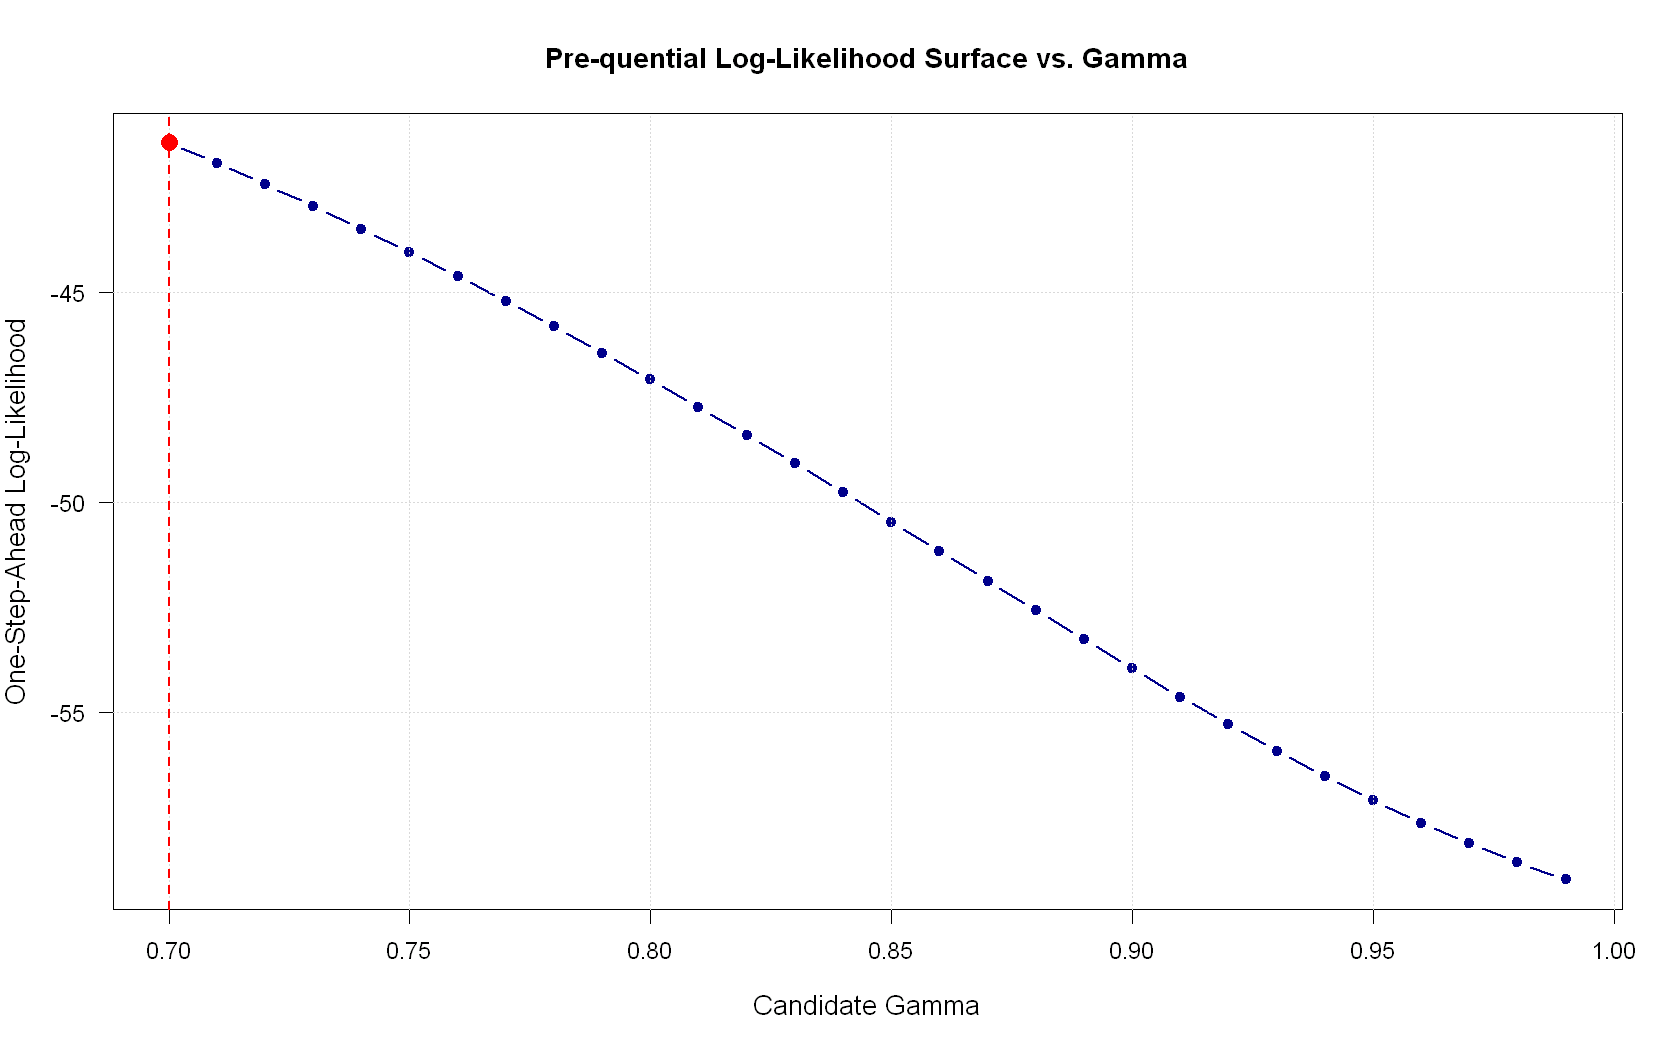

In [5]:
# Calibration Method 4: Backtesting Optimizer
log_beta_binom <- function(k, n, a, b) {
  lchoose(n, k) + lbeta(a + k, b + n - k) - lbeta(a, b)
}

evaluate_gamma <- function(g, k_vec, n_vec, a0 = 1, b0 = 19) {
  total_loglik <- 0
  brier_sum <- 0
  a <- a0; b <- b0
  for (t in seq_along(k_vec)) {
    ll <- log_beta_binom(k_vec[t], n_vec[t], a, b)
    pred_mean <- a / (a + b)
    obs_rate  <- k_vec[t] / n_vec[t]
    total_loglik <- total_loglik + ll
    brier_sum    <- brier_sum + (obs_rate - pred_mean)^2
    a <- g * a + k_vec[t]
    b <- g * b + (n_vec[t] - k_vec[t])
  }
  list(loglik = total_loglik, brier = brier_sum / length(k_vec))
}

gamma_candidates <- seq(0.70, 0.99, by = 0.01)
loglik_scores <- numeric(length(gamma_candidates))
brier_scores  <- numeric(length(gamma_candidates))

for (i in seq_along(gamma_candidates)) {
  res <- evaluate_gamma(gamma_candidates[i], daily_failures, rep(runs_per_day, days_total))
  loglik_scores[i] <- res$loglik
  brier_scores[i]  <- res$brier
}

best_idx <- which.max(loglik_scores)
best_gamma <- gamma_candidates[best_idx]

cat("=== Backtesting Optimization Results ===\n")
cat(sprintf("Optimal Gamma (Max Log-Likelihood) : %.2f (Score: %.2f)\n", best_gamma, loglik_scores[best_idx]))
cat(sprintf("Optimal Gamma (Min Brier Score)    : %.2f (Brier: %.5f)\n", 
            gamma_candidates[which.min(brier_scores)], min(brier_scores)))

plot(gamma_candidates, loglik_scores, type = "b", pch = 19, lwd = 2, col = "darkblue", las = 1,
     xlab = "Candidate Gamma", ylab = "One-Step-Ahead Log-Likelihood",
     main = "Pre-quential Log-Likelihood Surface vs. Gamma", cex.lab = 1.15, cex.main = 1.2)
grid(col = "gray85", lty = "dotted")
abline(v = best_gamma, col = "red", lty = 2, lwd = 2)
points(best_gamma, loglik_scores[best_idx], col = "red", pch = 19, cex = 1.6)
text(best_gamma - 0.04, loglik_scores[best_idx] - 2.5, sprintf("Optimal: gamma* = %.2f", best_gamma), col = "red", font = 2)


## Part 9: Advanced Architecture — Event-Triggered & Adaptive Decay

In modern enterprise pipelines, $\gamma$ does not have to be fixed permanently:
1. **Git Commit / Deployment Hooks**: Whenever a PR modifies a test's source file, trigger an instantaneous shock $\gamma_{\text{shock}} = 0.50$ (cutting old memory by half immediately).
2. **Surprise-Driven Adaptive Decay**: If observed daily failures deviate drastically from the prior predictive mean (high Mahalanobis distance), dynamically drop $\gamma$ to adapt quickly to regime shifts.
3. **Idle Decay**: If a test is not run for over a weekend (3 days of zero runs), apply $\gamma^3$ to reflect increased uncertainty over elapsed wall-clock time.

## Part 10: Production Cheat Sheet & Hands-On Exercises

### Rule-of-Thumb Decision Tree
- **Fast Sprint Cycle (1-2 weeks)**: Choose $\gamma = 0.88 - 0.92$ ($t_{1/2} \approx 5 - 8$ days).
- **Slow Enterprise Release (Monthly)**: Choose $\gamma = 0.95 - 0.97$ ($t_{1/2} \approx 14 - 23$ days).
- **High-Volume Continuous CI (>100 runs/day)**: Choose $\gamma = 0.95$, giving $N_{\text{eff}} = 2,000$ runs.

## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet. Write your solutions in the interactive attempt cells below before expanding the verified solutions.

---

### 🟢 Tier 1 (Warm-Up): The Half-Life of Empirical Evidence
> **Scenario**: A CI/CD reliability pipeline updates a test flakiness tracker daily with decay factor $\gamma = 0.95$.
> 1. Calculate the evidence half-life $t_{1/2} = \frac{\ln(0.5)}{\ln(\gamma)}$ in days.
> 2. How much weight does an execution that occurred $30\text{ days ago}$ retain relative to today's execution ($k = 30$)?
> 3. If a bug was introduced 30 days ago and then fixed, will the historical flakiness still trigger alarms?

In [ ]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
gamma <- 0.95

# 1. Compute evidence half-life in days:
# t_half <- log(0.5) / log(gamma)

# 2. Compute remaining weight after 30 days:
# weight_30 <- gamma^30

# cat(sprintf("Evidence Half-Life: %.2f days\n", t_half))
# cat(sprintf("Remaining weight after 30 days: %.2f%%\n", weight_30 * 100))


<details>
<summary><b>🔍 Click here to view the solution & derivation</b></summary>

**Answer**:
1. **Half-Life**:
   $$t_{1/2} = \frac{\ln(0.5)}{\ln(0.95)} = \frac{-0.69315}{-0.05129} \approx 13.5\text{ days}$$
2. **Remaining Weight**:
   $$w_{30} = \gamma^{30} = 0.95^{30} \approx 0.2146 = 21.46\%$$

```r
gamma <- 0.95
t_half <- log(0.5) / log(gamma)
weight_30 <- gamma^30
cat(sprintf('Half-life: %.1f days, Weight after 30 days: %.2f%%\n', t_half, weight_30*100))
```

3. **Engineering Impact**: After 30 days (more than two half-lives), nearly **$80\%$ of the bug's historical evidence has evaporated**. As long as recent runs pass, the posterior failure rate will rapidly decay below the quarantine threshold, automatically unblocking the deployment pipeline without manual database resets.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Steady-State Effective Sample Size ($N_{\text{eff}}$)
> **Scenario**: A payment gateway executes $n = 50$ health check transactions per batch. 
> The engineering team sets the discount factor to $\gamma = 0.90$.
> 1. Compute the steady-state effective sample size $N_{\text{eff}} = \frac{n}{1 - \gamma}$.
> 2. What would the effective sample size be if they tightened memory to $\gamma = 0.98$?
> 3. What is the fundamental engineering trade-off between $\gamma = 0.90$ and $\gamma = 0.98$?

In [ ]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
n <- 50  # tests per batch

# 1. Steady-state sample size under gamma = 0.90:
gamma_1 <- 0.90
# n_eff_1 <- n / (1 - gamma_1)

# 2. Steady-state sample size under gamma = 0.98:
gamma_2 <- 0.98
# n_eff_2 <- n / (1 - gamma_2)

# cat(sprintf("N_eff (gamma = 0.90): %.1f tests\n", n_eff_1))
# cat(sprintf("N_eff (gamma = 0.98): %.1f tests\n", n_eff_2))


<details>
<summary><b>🔍 Click here to view the solution & code</b></summary>

**Answer**:
1. For $\gamma = 0.90$:
   $$N_{\text{eff}} = \frac{50}{1 - 0.90} = \frac{50}{0.10} = 500\text{ runs}$$
2. For $\gamma = 0.98$:
   $$N_{\text{eff}} = \frac{50}{1 - 0.98} = \frac{50}{0.02} = 2,500\text{ runs}$$

```r
n <- 50
n_eff_90 <- n / (1.0 - 0.90)  # 50 / 0.10 = 500
n_eff_98 <- n / (1.0 - 0.98)  # 50 / 0.02 = 2500
cat(sprintf('N_eff (gamma=0.90): %.0f, N_eff (gamma=0.98): %.0f\n', n_eff_90, n_eff_98))
```

3. **Engineering Trade-off (Responsiveness vs. Variance)**:
   - $\gamma = 0.90$ ($N_{\text{eff}} = 500$): Extremely responsive to sudden degradations. Adapts within hours, but wider posterior credible intervals during quiet periods.
   - $\gamma = 0.98$ ($N_{\text{eff}} = 2,500$): Razor-thin credible intervals during steady-state, but sluggish to detect sudden outages because it takes thousands of observations to overcome historical inertia.
</details>

---

### 🔴 Tier 3 (Production Challenge): The Rolling Window Cliff-Edge Artifact
> **Scenario**: An SRE team monitors microservice error rates using a 30-day sliding rectangular window. 
> Exactly 31 days ago, a major database outage caused 500 requests to fail. 
> At midnight last night, day 31 fell off the back of the sliding window. 
> The dashboard suddenly showed a massive drop in estimated failure rate, and the on-call engineer received an automated alert: *"Anomaly: Sudden 80% improvement in error rate."*
> 1. Why does a rectangular sliding window produce this artificial "ghost signal"?
> 2. How does the exponential discount filter $\text{Beta}(\gamma \alpha_t, \gamma \beta_t)$ mathematically eliminate cliff-edge artifacts?

In [ ]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================
# Contrast:
# 1. 30-day rectangular sliding window: drops day t-30 with weight 1.0 -> 0.0 (cliff-edge)
# 2. Exponential discount filter (gamma): smooth weight gamma^k, no cliff edge

# Write your explanation and analysis below:


<details>
<summary><b>🔍 Click here to view the architectural comparison</b></summary>

**Architectural Comparison**:
1. **The Cliff-Edge Pathology of Rectangular Windows**:
   A sliding window assigns a step-function weight to evidence:
   $$w(k) = \begin{cases} 1.0 & \text{if } k \le 30 \text{ days} \\ 0.0 & \text{if } k > 30 \text{ days} \end{cases}$$
   When an extreme event (e.g., 500 failures) reaches age $k = 31$, its weight abruptly collapses from $1.0$ to $0.0$ in a single timestep. This produces a **phantom discontinuity** in the metric that has nothing to do with current system performance.
2. **Exponential Smoothing Guarantee**:
   The Bayesian exponential decay assigns smooth geometric weighting:
   $$w(k) = \gamma^k$$
   Because $\gamma^k - \gamma^{k+1} = \gamma^k(1 - \gamma)$ is continuous and infinitesimal for each step, past events fade smoothly toward zero:
   - There is no cliff-edge, no arbitrary cutoff date, and no ghost signals.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 5: Production Scale — Multi-Chain MCMC & Diagnostics](05_mcmc_production_diagnostics.ipynb) | ⏭️ Next: [Sheet 7: Actionable Systems — Bayesian Decision Theory & Predictive Checks](07_bayesian_decision_theory_and_predictive_checks.ipynb)**